# Titanic Survival Prediction

## Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.typing import NDArray
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

%matplotlib inline

## Titanic Passenger dataset

<p>We'll be working with the Titanic passenger dataset to build a classification model to predict whether a passenger survived the sinking of the Titanic. Here is the data dictionary:</p>
<table style="border-collapse: collapse">
<thead>
<tr>
    <th style="border: 1px solid; text-align: left">Variable</th>
    <th style="border: 1px solid; text-align: left">Definition</th>
</tr>
</thead>
<tbody>
<tr>
    <td style="border: 1px solid; text-align: left">survived</td>
    <td style="border: 1px solid; text-align: left">0 = No, 1 = Yes.</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">pclass</td>
    <td style="border: 1px solid; text-align: left">Ticket class (int)</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">sex</td>
    <td style="border: 1px solid; text-align: left">sex</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">age</td>
    <td style="border: 1px solid; text-align: left">age in years</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">sibsp</td>
    <td style="border: 1px solid; text-align: left"># of siblings / spouses aboard the Titanic</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">parch</td>
    <td style="border: 1px solid; text-align: left"># of parents / children aboard the Titanic</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">fare</td>
    <td style="border: 1px solid; text-align: left">Passenger fare</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">embarked</td>
    <td style="border: 1px solid; text-align: left">Port of Embarkation</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">class</td>
    <td style="border: 1px solid; text-align: left">Ticket class</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">who</td>
    <td style="border: 1px solid; text-align: left">man, woman, or child</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">adult_male</td>
    <td style="border: 1px solid; text-align: left">True / False</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">alive</td>
    <td style="border: 1px solid; text-align: left">yes / no</td>
</tr>
<tr>
    <td style="border: 1px solid; text-align: left">alone</td>
    <td style="border: 1px solid; text-align: left">yes / no</td>
</tr>
</tbody>
</table>

## Load the Titanic dataset using `seaborn`

In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Select relevant features and the target

In [3]:
titanic.count()

survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64

### Features to drop

<p><code>deck</code> has a lot of missing values so we'll drop it. <code>age</code> has quite a few missing values as well. Although it could be, <code>embarked</code> and <code>embark_town</code> don't seem relevant so we'll drop them as well. It's unclear what <code>alive</code> refers to so we'll ignore it.</p>

### Target

<p><code>survived</code> is our target class variable.</p>

In [4]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "class", "who", "adult_male", "alone"]
target = "survived"

X = titanic.loc[:, features]
y = titanic.loc[:, target]

y.value_counts()

survived
0    549
1    342
Name: count, dtype: int64

<p>About 38% of the passengers in the dataset survived. Because of this slight imbalance, we should stratify the data when performing train/test split and for cross-validation.</p>

## Split the data into training and testing sets

In [5]:
split_data: list[pd.DataFrame | pd.Series] = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_test, y_train, y_test = split_data

## Define preprocessing transformers for numerical and categorical features

<p>Altomatically detect numerical and categorical columns and assign them to separate numeric and categorical features.</p>

In [6]:
numerical_features = X_train.select_dtypes(include=["number"]).columns.to_list()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.to_list()

## Define separate preprocessing pipelines for both feature types

In [7]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

### Combine the transformers into a single column transformer

<p>We'll use the <code>scikit-learn</code>'s <code>ColumnTransformer</code> estimator to separately transform the features, which will then concatenate the output as a single feature space, ready for input to a machine learning estimator.</p>

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

## Create a model pipeline

<p>Now let's complete the model pipeline by combining the preprocessing with a <code>RandomForestClassifier</code>.</p>

In [9]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

## Define a parameter grid

<p>We'll use the grid in a cross validation search to optimize the model.</p>

In [10]:
param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

## Perform grid search cross-validation and fit the best model to the training data

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Train the pipeline model

In [12]:
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring="accuracy", verbose=2)
model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## Get the model predictions from the grid search estimator on the unseen data

In [13]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



## Plot the confusion matrix

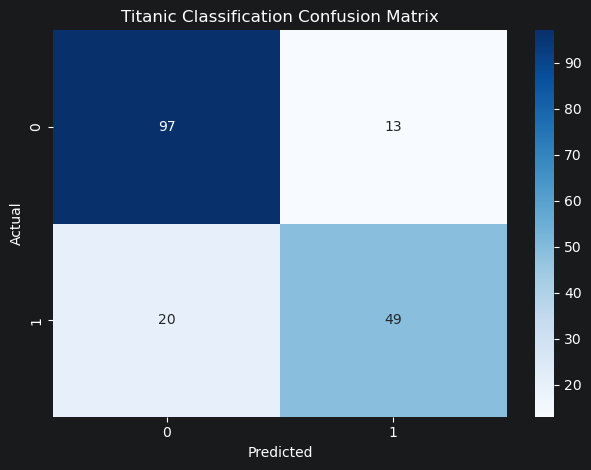

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.title("Titanic Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

## Feature Importances

<p>Let's figure out how to get the feature importances of our overall model. First, to obtain the categorical feature importances, we have to work our way backward through the modelling pipeline to associate the feature importances with their one-hot encoded input features that were transformed from the original categorical features.</p>
<p>We don't need to trace back through the pipeline for the numerical features, because we didn't transform them into new ones in any way. Remember, we went fron categorical features to one-hot encoded features, using the <code>cat</code> column transformer.</p>
<p>Here's how you trace back through the trained model to access the one-hot encoded feature names:</p>

In [15]:
model.best_estimator_["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

<p>Notice how the one-hot encoded features are named. For example, <code>sex</code> was split into two boolean features indicating whether the sex is male or female.</p>
<p>Now let's get all of the feature importances and associate them with their transformed feature names.</p>

In [16]:
feature_importances = model.best_estimator_["classifier"].feature_importances_

feature_names = [*numerical_features, *model.best_estimator_["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features).tolist()]

## Display the feature importances in a bar plot

Test set accuracy: 81.56%


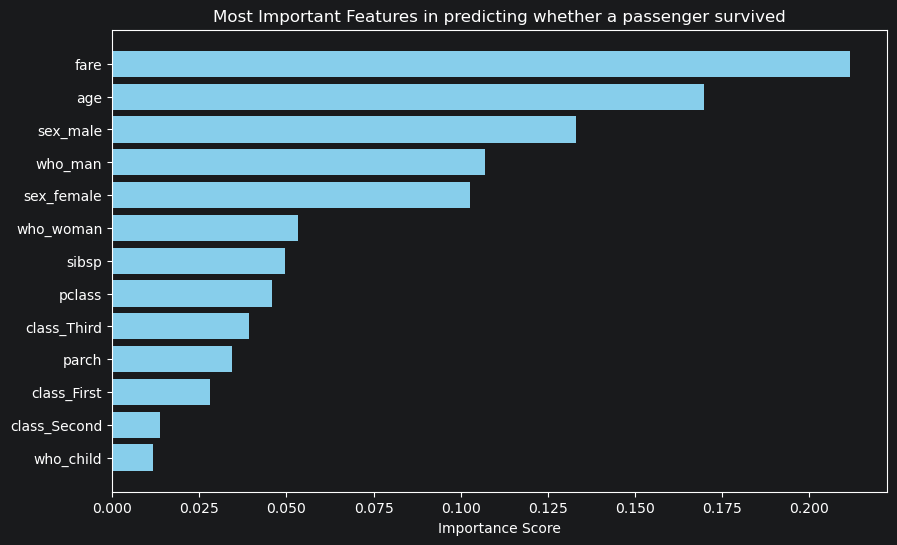

In [17]:
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df.loc[:, "Feature"], importance_df.loc[:, "Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("Most Important Features in predicting whether a passenger survived")
plt.xlabel("Importance Score")

print(f"Test set accuracy: {model.score(X_test, y_test):.2%}")

<p>The test set accuracy is somewhat satisfactory. However, regarding the feature importances, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, no doubt there is significant information shared by the variables <code>age</code>, <code>sex_male</code> and <code>who_man</code>.</p>

## Try another model

<p>In practice you would want to try out different models and even revisit the data analysis to improve your model performance. Maybe you can engineer new features or impute missing values to be able to use more data.</p>
<p>With <code>scikit-learn</code>'s powerful <code>Pipeline</code> class, this is easy to do in a few steps. Let's update the pipeline and the parameter grid so we can train a Logistic Regression model and compare the performance of the two models.</p>

In [18]:
pipeline.set_params(**{"classifier": LogisticRegression(random_state=42)})
model.estimator = pipeline

param_grid = {
    "classifier__solver": ["liblinear"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"]
}
model.param_grid = param_grid

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

## Display the classification report for the new model and compare the results to your previous model

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



<p>All of the scores are slightly better for logistic regression than for random forest classification, although the differences are insignificant.</p>

## Display the confusion matrix for the new model and compare the results to your previous model

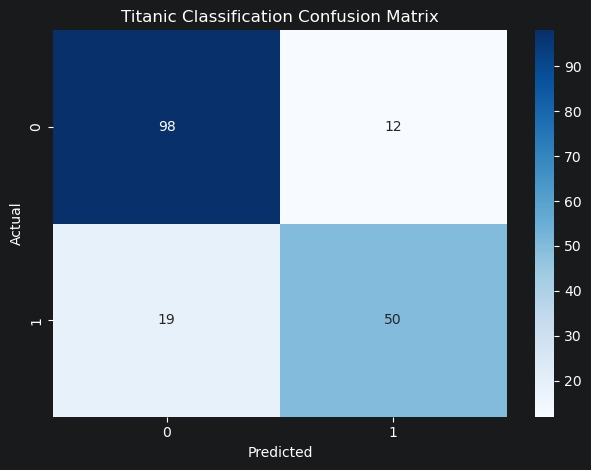

In [20]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Titanic Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

## Extract the logistic regression feature coefficients and plot their magnitude in a bar chart

In [21]:
coefficients: NDArray[np.float64] = model.best_estimator_.named_steps["classifier"].coef_.ravel()
numerical_feature_names = numerical_features
categorical_feature_names: NDArray[np.object_] = model.best_estimator_.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)

feature_names = [*numerical_feature_names, *categorical_feature_names.tolist()]

## Plot the feature coefficient magnitudes in a bar chart

Test set accuracy: 82.68%


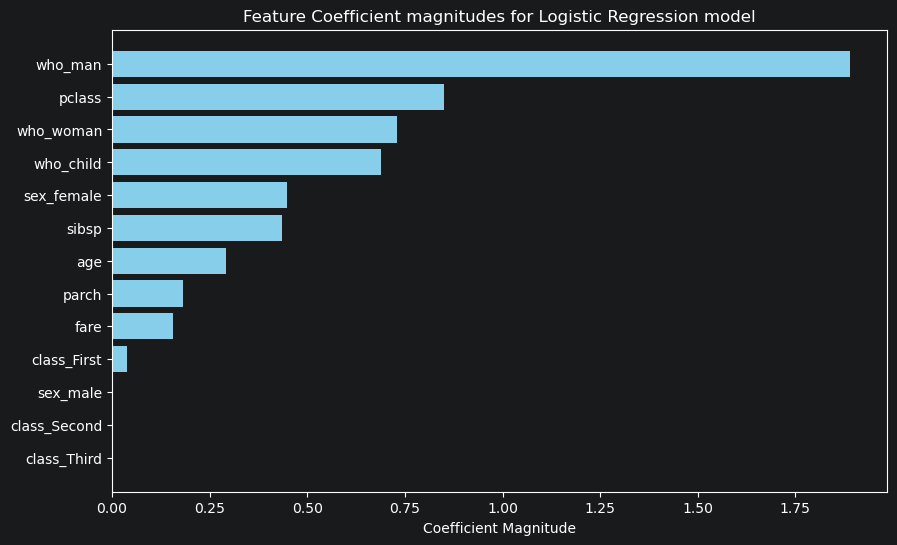

In [22]:
importance_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients}).sort_values(by="Coefficient", ascending=False, key=abs)

plt.figure(figsize=(10, 6))
plt.barh(importance_df.loc[:, "Feature"], importance_df.loc[:, "Coefficient"].abs(), color="skyblue")
plt.gca().invert_yaxis()
plt.title("Feature Coefficient magnitudes for Logistic Regression model")
plt.xlabel("Coefficient Magnitude")

print(f"Test set accuracy: {model.best_estimator_.score(X_test, y_test):.2%}")

<p>Although the performances of the two models are virtually identical, the features that are important to the two models are very different. This suggusts there must be more work to do to better grasp the actual feature importances. As mentioned above, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, there is significant information implied between the variables <code>who_man</code>, <code>who_woman</code>, and <code>who_child</code>, because if a person is neither a man nor a woman, then they must be a child.</p>

****
This is the end of the file.
****